In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from scipy import stats
from os.path import join
from pathlib import Path
import numpy as np
import pathlib
from typing import Dict, List

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

In [3]:
from mylib import genomes

In [4]:
population_dict = {
    "ASW": "African Ancestry, USA",
    "ACB": "African Caribbean, Barbados",
    "BEB": "Bengali, Bangladesh",
    "GBR": "British, England and Scotland",
    "CDX": "Chinese Dai, China",
    "CLM": "Colombian, Colombia",
    "ESN": "Esan, Nigeria",
    "FIN": "Finnish, Finland",
    "GWD": "Gambian Mandinka, Gambia",
    "GIH": "Gujarati Indian, USA",
    "CHB": "Han Beijing, China",
    "CHS": "Han South, China",
    "IBS": "Iberian, Spain",
    "ITU": "Indian Telugu, UK",
    "JPT": "Japanese, Japan",
    "KHV": "Kinh, Vietnam",
    "LWK": "Luhya, Kenya",
    "MSL": "Mende, Sierra Leone",
    "MXL": "Mexican Ancestry, USA",
    "PEL": "Peruvian, Peru",
    "PUR": "Puerto Rican, Puerto Rico",
    "PJL": "Punjabi, Pakistan",
    "STU": "Sri Lankan Tamil, UK",
    "TSI": "Toscani, Italy",
    "YRI": "Yoruba, Nigeria"
}


In [5]:
root_dir = join(Path.home(),"projects/cp_als/populations")

In [6]:
focused_population = "ESN"

In [7]:
compared_populations = ["ASW","ACB", "ITU", "BEB","GBR","CDX","CLM","KHV","FIN","GWD","GIH","CHB","CHS","IBS","JPT","LWK","MSL","MXL","PEL","PUR","PJL","STU","TSI","YRI"]

In [8]:
#indir = join(Path.home(),"projects/cp_als/populations")
file_path = join(root_dir, f"output/{focused_population}/all.csv")
df = pd.read_csv(file_path)

In [9]:
genes = list(df['gene'].unique())
print(genes)

['ALS2', 'ANG', 'ATXN2', 'C19ORF12', 'C9ORF72', 'CHCHD10', 'CHMP2B', 'CHRNA3', 'CREST', 'DAO', 'DCTN1', 'ELP3', 'ERBB4', 'EWSR1', 'FIG4', 'FUS', 'MATR3', 'NEFH', 'NEK1', 'OPTN', 'PFN1', 'PNPLA6', 'PON1-3', 'PRPH', 'SETX', 'SIGMAR1', 'SOD1', 'SPG11', 'SQSTM1', 'TAF15', 'TARDBP', 'TUBA4A', 'VAPB', 'VCP', 'hnRNPA2B1', 'hnRNPa1']


In [10]:
populations = [c for c in genomes if c != focused_population]

In [11]:
hdf = pd.DataFrame(columns=populations,index=genes)
hdf

,ACB,ASW,BEB,CDX,CHB,CHS,CLM,FIN,GBR,GIH,...,KHV,LWK,MSL,MXL,PEL,PJL,PUR,STU,TSI,YRI
ALS2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ANG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ATXN2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
C19ORF12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
C9ORF72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CHCHD10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CHMP2B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CHRNA3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CREST,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DAO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
hdf = hdf.drop(index=["FUS", "SOD1", "TARDBP", "CHMP2B"], errors="ignore")
hdf.shape

(32, 24)

In [13]:
def get_total_variant_count(root_dir,important_gene,populations,genomes):
    total_variant_count = []
    for pop_name,genome_list in genomes.items():
        if pop_name not in populations:
            continue
        file_path = join(root_dir,f"output/{pop_name}/all.csv")
        df = pd.read_csv(file_path)
        df = df[df['gene'] == important_gene]
        filtered_genomes = [g for g in genome_list if g in df.columns]
        df_filtered = df[filtered_genomes]
        total_count = df_filtered.sum()
        total_variant_count.append(total_count.values)
    return total_variant_count

In [14]:
for important_gene in genes:
    for population in populations:
        population_pair = [focused_population, population]
        total_variant_count = get_total_variant_count(root_dir = root_dir, important_gene = important_gene,
                                                      populations = population_pair, genomes=genomes)
        t_statistic, p_value = stats.ttest_ind(total_variant_count[0],total_variant_count[1])
        hdf.at[important_gene,population_pair[1]] = p_value

In [15]:
hdf.dropna(axis=1,how='all',inplace=True)

In [16]:
hdf.dropna(axis=0,how='any',inplace=True)

In [17]:
hdf.shape

(36, 24)

In [18]:
hdf

,ACB,ASW,BEB,CDX,CHB,CHS,CLM,FIN,GBR,GIH,...,KHV,LWK,MSL,MXL,PEL,PJL,PUR,STU,TSI,YRI
ALS2,0.549224,0.067362,0.000006,0.0,0.0,0.0,0.003392,0.000003,0.000201,0.000104,...,0.0,0.27777,0.038788,0.007827,0.002491,0.0,0.002832,0.000016,0.000001,0.290314
ANG,0.367198,0.715234,0.0,0.0,0.00001,0.0,0.0,0.008749,0.000004,0.000028,...,0.0,0.929421,0.370785,0.014513,0.401519,0.000021,0.000758,0.000082,0.00364,0.588962
ATXN2,0.417964,0.401966,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.311784,0.101365,0.0,0.0,0.0,0.0,0.0,0.0,0.14493
C19ORF12,0.062088,0.436137,0.0,0.0,0.0,0.000003,0.0,0.0,0.0,0.0,...,0.000002,0.019374,0.774443,0.000001,0.000009,0.0,0.0,0.0,0.0,0.739821
C9ORF72,0.721675,0.448254,0.00295,0.029777,0.086177,0.03407,0.107968,0.000014,0.003089,0.00004,...,0.008515,0.111249,0.195857,0.003901,0.058949,0.00005,0.019069,0.000559,0.089864,0.890627
CHCHD10,0.756123,0.35677,0.0,0.0,0.0,0.0,0.305728,0.582881,0.115213,0.0,...,0.0,0.912485,0.292311,0.012707,0.000052,0.0,0.944167,0.0,0.761664,0.360249
CHRNA3,0.559674,0.90019,0.398605,0.023647,0.003546,0.007589,0.121685,0.625471,0.074532,0.253834,...,0.007023,0.048731,0.481386,0.015595,0.0,0.536388,0.724463,0.054692,0.747699,0.369401
CREST,0.457142,0.000417,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.412338,0.92975,0.0,0.0,0.0,0.0,0.0,0.0,0.227441
DAO,0.909711,0.438859,0.000001,0.000319,0.016158,0.317176,0.001781,0.0,0.0,0.000004,...,0.09454,0.34009,0.435176,0.447082,0.011055,0.000018,0.001412,0.000001,0.0,0.589861
DCTN1,0.010146,0.000208,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.244278,0.26876,0.0,0.0,0.0,0.0,0.0,0.0,0.783053


In [19]:
hdf.columns

Index(['ACB', 'ASW', 'BEB', 'CDX', 'CHB', 'CHS', 'CLM', 'FIN', 'GBR', 'GIH',
       'GWD', 'IBS', 'ITU', 'JPT', 'KHV', 'LWK', 'MSL', 'MXL', 'PEL', 'PJL',
       'PUR', 'STU', 'TSI', 'YRI'],
      dtype='object')

# Removing two genes with repeats: ATXN2 and C9ORF72

In [20]:
hdf.drop(["ATXN2", "C9ORF72"], inplace=True)

In [21]:
hdf_float = hdf.apply(pd.to_numeric,errors='coerce')

In [22]:
hdf_rounded = hdf_float.round(3)
hdf_rounded = hdf_rounded[compared_populations]
hdf_rounded.shape


(34, 24)

In [23]:
pop_to_continent = {
    # Africa
    "ACB": "Africa",
    "GWD": "Africa",
    "LWK": "Africa",
    "MSL": "Africa",
    "YRI": "Africa",
    "ASW": "Africa",
    # Americas
    "CLM": "Americas",
    "MXL": "Americas",
    "PEL": "Americas",
    "PUR": "Americas",

    # East Asia
    "CDX": "East Asia",
    "CHB": "East Asia",
    "CHS": "East Asia",
    "JPT": "East Asia",
    "KHV": "East Asia",

    # Europe
    "FIN": "Europe",
    "GBR": "Europe",
    "IBS": "Europe",
    "TSI": "Europe",

    # South Asia
    "BEB": "South Asia",
    "GIH": "South Asia",
    "ITU": "South Asia",
    "PJL": "South Asia",
    "STU": "South Asia",
}

In [24]:
compared_populations_sorted = sorted(compared_populations, key=lambda x: pop_to_continent[x])
hdf_rounded = hdf_rounded[compared_populations_sorted]
continent_order = [pop_to_continent[p] for p in compared_populations_sorted]

In [25]:
from matplotlib.colors import BoundaryNorm

bounds = [0,0.051,0.1,0.5,0.75,1.0]
cmap = plt.cm.get_cmap("Greens_r", len(bounds)-1)
norm = BoundaryNorm (boundaries=bounds,ncolors = cmap.N)

/var/folders/mk/qv7kjtr17ls_fqfn64hdptt00000gn/T/ipykernel_11246/722416586.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Greens_r", len(bounds)-1)


In [26]:
selected_genes = ["ANG", "VCP", "NEK1"]

/var/folders/mk/qv7kjtr17ls_fqfn64hdptt00000gn/T/ipykernel_11246/168467200.py:22: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_data = hdf_subset.applymap(format_value)
/var/folders/mk/qv7kjtr17ls_fqfn64hdptt00000gn/T/ipykernel_11246/168467200.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Greens_r", len(bounds) - 1)


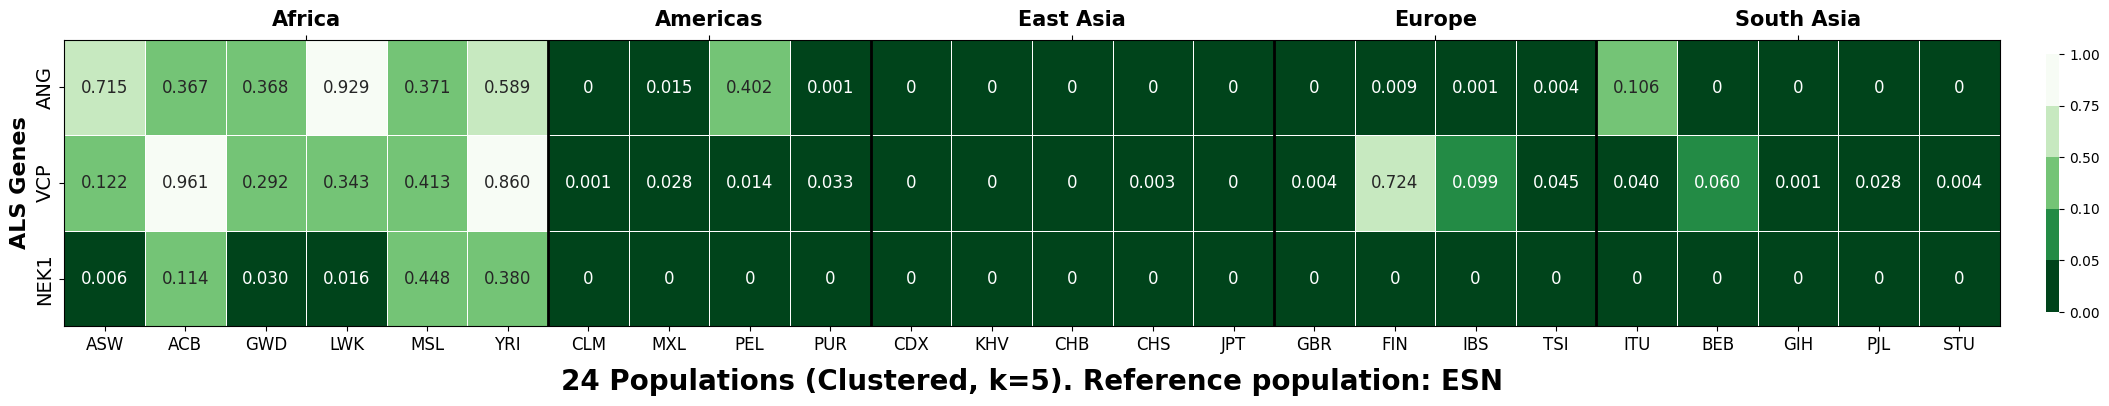

In [27]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import BoundaryNorm

# -----------------------------------
# Filter to selected genes
# -----------------------------------

hdf_subset = hdf_rounded.loc[selected_genes]

# -----------------------------------
# Format annotations: 0.0000 → "0"
# -----------------------------------
def format_value(x):
    if np.isclose(x, 0):
        return "0"
    return f"{x:.3f}"

annot_data = hdf_subset.applymap(format_value)

# -----------------------------------
# Create folder if needed
# -----------------------------------
#os.makedirs("plots", exist_ok=True)

# -----------------------------------
# Plot (wide for full LaTeX width)
# -----------------------------------
plt.figure(figsize=(24, 4))  # wider + shorter

bounds = [0, 0.051, 0.1, 0.5, 0.75, 1.0]
cmap = plt.cm.get_cmap("Greens_r", len(bounds) - 1)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

ax = sns.heatmap(
    hdf_subset,
    cmap=cmap,
    norm=norm,
    annot=annot_data,
    fmt="",
    annot_kws={"size": 12},
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.9, "pad": 0.02}
)

# -----------------------------------
# Vertical continent separators
# -----------------------------------
boundaries = [
    i for i in range(1, len(continent_order))
    if continent_order[i] != continent_order[i - 1]
]

for b in boundaries:
    ax.axvline(b, color="black", linewidth=2)

# -----------------------------------
# Continent labels on top
# -----------------------------------
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())

group_positions = []
group_labels = []

for cont, pops in pd.Series(continent_order).groupby(continent_order):
    mid = (pops.index[0] + pops.index[-1]) / 2
    group_positions.append(mid + 0.5)
    group_labels.append(cont)

ax2.set_xticks(group_positions)
ax2.set_xticklabels(group_labels, fontsize=15, fontweight="bold")

# -----------------------------------
# Axis labels (NO TITLE)
# -----------------------------------
ax.set_xlabel(
    # f"{hdf_subset.shape[1]} Populations (Clustered, k=5)",
    f"{hdf_subset.shape[1]} Populations (Clustered, k=5). Reference population: {focused_population}",

    fontsize=20,
    fontweight="bold",
    labelpad=10
)

ax.set_ylabel(
    "ALS Genes",
    fontsize=16,
    fontweight="bold"
)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=14)

# -----------------------------------
# Layout tuning for LaTeX
# -----------------------------------
plt.tight_layout(pad=0.5)

# -----------------------------------
# Save (PDF > PNG for LaTeX)
# -----------------------------------
# output_file = "plots/als_major_genes_heatmap.pdf"
# plt.savefig(output_file, bbox_inches="tight")
# output_file = "plots/figure_3.png"
# plt.savefig(output_file, dpi=300, bbox_inches="tight", facecolor="white")
#plt.close()
plt.show()

#print(f"Saved: {output_file}")